In [1]:
%load_ext autoreload
%autoreload 2
from clusters.HierarchicalCluster import HierarchicalCluster
from utils.util import *
from utils.process_datasets import *

d:\anaconda3\envs\LLM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import logging
from models.ConcatModel import ConcatModel
from models.SingleModel import SingleModel
from models.ManualModel import ManualModel
from models.FinalModel import FinalModel
from config import *

In [3]:
from torch.utils.data import DataLoader, SequentialSampler


In [4]:
args=parse_jit_args()
args.cluster_model=f"project_f_1e-4"
args.base_model="concat"
args.pretrained_model="codebert"

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.n_gpu = len(args.available_gpu)
args.device = device
torch.cuda.set_device(args.available_gpu[0])

logging.basicConfig(format='%(asctime)s - %(levelname)s - %(name)s - %(message)s', datefmt='%m/%d/%Y %H:%M:%S',
                    level=logging.INFO)

set_seed(args)

model, tokenizer, config = build_model_tokenizer_config(args)

####################################### Load datasets ######################################################
train_dataset_dict = load_project_datas(tokenizer, args, "train")
####################################### 层次聚类 #########################################
fcluster=HierarchicalCluster(args)
fcluster.fit(train_dataset_dict)

if args.base_model == "concat":
    mymodel = ConcatModel(model, config, tokenizer, args).to(device)
elif args.base_model == "single":
    mymodel = SingleModel(model, config, tokenizer, args).to(device)
elif args.base_model == "manual":
    mymodel = ManualModel(model, config, tokenizer, args).to(device)
else:
    raise ValueError(f"Invalid base model: {args.base_model}")

test_dataset_dict = load_project_datas(tokenizer, args, "test")
############################# 层次聚类 ####################################
test_dataset_dict = fcluster.splitDatasets(test_dataset_dict)

model_name=f"{args.base_model}-{args.pretrained_model}-final.pt"
save_dir=os.path.join(args.output_dir, f"checkpoints/{args.base_model}")
checkpoint = torch.load(os.path.join(save_dir,model_name),weights_only=True)
mymodel.load_state_dict(checkpoint)

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


<All keys matched successfully>

In [6]:
isolation_result=dict()
LOF_result=dict()
ma_result=dict()
svm_result=dict()
tri_result=dict()

In [7]:
pred_label=dict()
base_label=dict()
true_label=dict()

In [8]:
global_true_label=[]
for project_name,test_cluster_datasets in test_dataset_dict.items():
    local_true_label=[]
    print(f"Project: {project_name}: {len(test_cluster_datasets)} samples.")
    test_sampler = SequentialSampler(test_cluster_datasets)
    test_dataloader = DataLoader(test_cluster_datasets, sampler=test_sampler, batch_size=args.batch_size)
    for batch in test_dataloader:
        input_ids, input_mask, manual_features, label = [x for x in batch]
        local_true_label.append(label.detach().numpy())
    local_true_label=np.concatenate(local_true_label,axis=0)
    # print(local_true_label)
    true_label[project_name]=local_true_label
    global_true_label.append(local_true_label)
global_true_label=np.concatenate(global_true_label,axis=0)
true_label["all"]=global_true_label
# print(f"global:{len(global_true_label)},{global_true_label}")

Project: 1: 2913 samples.
Project: 2: 673 samples.
Project: 3: 1171 samples.
Project: 4: 723 samples.


In [9]:
# run for lora model

with torch.no_grad():
    pred_result=[]
    mymodel.eval()
    finalModel=FinalModel(args,mymodel,fcluster)
    finalModel.eval()
    global_pred_prob=[]
    for project_name, test_cluster_datasets in test_dataset_dict.items():
        print(project_name)
        local_pred = []
        print(f"Project: {project_name}: {len(test_cluster_datasets)} samples.")
        test_sampler = SequentialSampler(test_cluster_datasets)
        test_dataloader = DataLoader(test_cluster_datasets, sampler=test_sampler, batch_size=args.batch_size)
        # load lora
        finalModel.load_lora(
            os.path.join(LORA_DIR, f"{args.cluster_model}/{args.base_model}/{args.pretrained_model}/{project_name}"),
            lora_name=str(project_name))
        finalModel.change_loras(str(project_name))
        for batch in test_dataloader:
            # check outlier samples
            input_ids, input_mask, manual_features, label = [x.to(args.device) for x in batch]
            with torch.no_grad():
                ###############Run for lora without mask
                prob, loss = finalModel(input_ids, input_mask, manual_features, label,use_base=False)
                prob=prob.detach().cpu().numpy().reshape(-1)
                pred=np.where(prob<0.5,0,1)
                local_pred.append(pred)
        local_pred=np.concatenate(local_pred,axis=0)
        pred_result.append(local_pred)
        pred_label[project_name]=local_pred
    pred_result=np.concatenate(pred_result,axis=0)
    pred_label["all"]=pred_result

1
Project: 1: 2913 samples.
2
Project: 2: 673 samples.
3
Project: 3: 1171 samples.
4
Project: 4: 723 samples.


In [10]:
# run for base model
with torch.no_grad():
    base_result=[]
    mymodel.eval()
    finalModel=mymodel
    finalModel.eval()
    global_pred_prob=[]
    for project_name, test_cluster_datasets in test_dataset_dict.items():
        print(project_name)
        local_pred = []
        print(f"Project: {project_name}: {len(test_cluster_datasets)} samples.")
        test_sampler = SequentialSampler(test_cluster_datasets)
        test_dataloader = DataLoader(test_cluster_datasets, sampler=test_sampler, batch_size=args.batch_size)
        for batch in test_dataloader:
            # check outlier samples
            input_ids, input_mask, manual_features, label = [x.to(args.device) for x in batch]
            with torch.no_grad():
                ###############Run for lora without mask
                prob, loss = finalModel(input_ids, input_mask, manual_features, label)
                prob=prob.detach().cpu().numpy().reshape(-1)
                pred=np.where(prob<0.5,0,1)
                local_pred.append(pred)
        local_pred=np.concatenate(local_pred,axis=0)
        base_result.append(local_pred)
        base_label[project_name]=local_pred
    base_result=np.concatenate(base_result,axis=0)
    base_label["all"]=base_result

1
Project: 1: 2913 samples.
2
Project: 2: 673 samples.
3
Project: 3: 1171 samples.
4
Project: 4: 723 samples.


In [11]:
def extract_expert_features(data,cluster_target=2):
    """extract expert features from JITFine Dataset"""
    return np.stack([item[cluster_target] for item in data], axis=0)

In [12]:
for strategy,result_dict in zip(["Isolation","Lof","svm","Mahalanobis","tri"],[isolation_result,LOF_result,svm_result,ma_result,tri_result]):
    all_outlier=[]
    for project_name, test_cluster_datasets in test_dataset_dict.items():
        outlier_mask=fcluster.checkOutliers(extract_expert_features(test_cluster_datasets),str(project_name),strategy)
        result_dict[project_name]=outlier_mask
        all_outlier.append(outlier_mask)
    all_outlier=np.concatenate(all_outlier,axis=0)
    result_dict["all"]=all_outlier

In [13]:
wrong_sample=(pred_label["all"]!=true_label["all"])

In [14]:
wrong_sample.sum()/len(wrong_sample)

np.float64(0.10401459854014598)

In [52]:
def true_label_getter(pred_label,true_label,base_label):
    base_correct=(base_label==true_label)
    lora_wrong=(pred_label!=true_label)
    return (base_correct & lora_wrong)

In [53]:
len(true_label_getter(pred_label[1],true_label[1],base_label[1]))

2913

In [54]:
from sklearn.metrics import recall_score,accuracy_score,precision_score
import pandas as pd

In [ ]:
acc_data=[]
for strategy,result_dict in zip(["Isolation","Lof","svm","Mahalanobis","tri"],[isolation_result,LOF_result,svm_result,ma_result,tri_result]):
    acc_data.append([
        accuracy_score(true_label_getter(pred_label[x],true_label[x],base_label[x]),result_dict[x]) for x in [1,2,3,4,"all"]
    ])
acc_data=np.array(acc_data).T
acc_df=pd.DataFrame(acc_data,index=[1,2,3,4,"all"],columns=["Isolation","Lof","svm","Mahalanobis","tri"])

TypeError: missing a required argument: 'y_pred'

In [17]:
acc_df

,Isolation,Lof,svm,Mahalanobis,tri
1,0.617233,0.494679,0.434604,0.407827,0.498455
2,0.790490,0.485884,0.493314,0.374443,0.557207
3,0.676345,0.585824,0.623399,0.545687,0.622545
4,0.478562,0.302905,0.269710,0.443983,0.378976
all,0.632847,0.487774,0.460401,0.437956,0.516423


<Axes: >

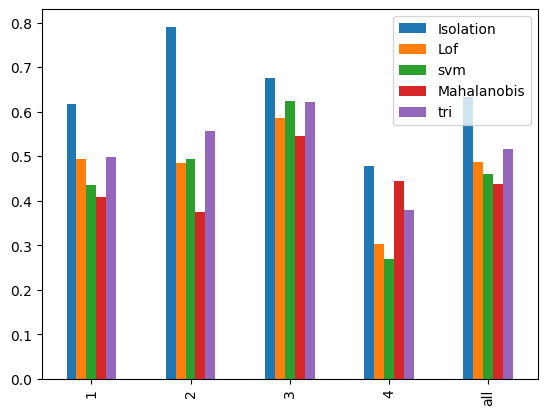

In [18]:
acc_df.plot.bar()

In [ ]:
recall_data=[]
for strategy,result_dict in zip(["Isolation","Lof","svm","Mahalanobis","tri"],[isolation_result,LOF_result,svm_result,ma_result,tri_result]):
    recall_data.append([
        recall_score(true_label_getter(pred_label[x],true_label[x],base_label[x]),result_dict[x]) for x in [1,2,3,4,"all"]
    ])
recall_data=np.array(recall_data)
recall_data=recall_data.T
recall_df=pd.DataFrame(recall_data,index=[1,2,3,4,"all"],columns=["Isolation","Lof","svm","Mahalanobis","tri"])

In [20]:
recall_df

,Isolation,Lof,svm,Mahalanobis,tri
1,0.384906,0.286792,0.471698,0.641509,0.449057
2,0.417582,0.450549,0.648352,0.846154,0.659341
3,0.504505,0.459459,0.576577,0.747748,0.594595
4,0.543689,0.533981,0.582524,0.611650,0.582524
all,0.442105,0.391228,0.540351,0.689474,0.535088


<Axes: >

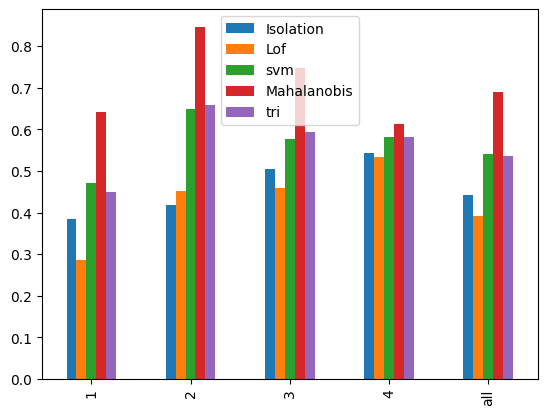

In [21]:
recall_df.plot.bar()

In [ ]:
precision_data=[]
for strategy,result_dict in zip(["Isolation","Lof","svm","Mahalanobis","tri"],[isolation_result,LOF_result,svm_result,ma_result,tri_result]):
    precision_data.append([
        precision_score(true_label_getter(pred_label[x],true_label[x],base_label[x]),result_dict[x]) for x in [1,2,3,4,"all"]
    ])
precision_data=np.array(precision_data).T
precision_df=pd.DataFrame(precision_data,index=[1,2,3,4,"all"],columns=["Isolation","Lof","svm","Mahalanobis","tri"])

In [35]:
precision_df

,Isolation,Lof,svm,Mahalanobis,tri
1,0.096774,0.055923,0.076593,0.094444,0.082985
2,0.301587,0.121662,0.160326,0.159091,0.183486
3,0.147368,0.107143,0.139738,0.141397,0.142549
4,0.145078,0.107632,0.110092,0.148235,0.128755
all,0.129496,0.083116,0.102564,0.119235,0.113383


<Axes: >

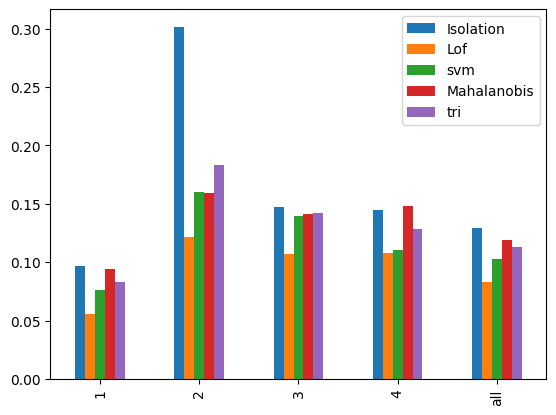

In [36]:
precision_df.plot.bar()

In [42]:
def gmean_score(true_label,pred_label):
    return np.sqrt(
            recall_score(true_label, pred_label, pos_label=0, average="binary") *
            recall_score(true_label, pred_label, average="binary")
        )

In [ ]:
gmean_data=[]
for strategy,result_dict in zip(["Isolation","Lof","svm","Mahalanobis","tri"],[isolation_result,LOF_result,svm_result,ma_result,tri_result]):
    gmean_data.append([
        gmean_score(true_label_getter(pred_label[x],true_label[x],base_label[x]),result_dict[x]) for x in [1,2,3,4,"all"]
    ])
gmean_data=np.array(gmean_data).T
gmean_df=pd.DataFrame(gmean_data,index=[1,2,3,4,"all"],columns=["Isolation","Lof","svm","Mahalanobis","tri"])

In [44]:
gmean_df

,Isolation,Lof,svm,Mahalanobis,tri
1,0.496514,0.384495,0.450833,0.496611,0.475452
2,0.595351,0.470536,0.551474,0.504408,0.597377
3,0.591859,0.524635,0.601884,0.626271,0.609838
4,0.504288,0.375828,0.356146,0.504505,0.448403
all,0.538121,0.441832,0.493724,0.530874,0.524569


<Axes: >

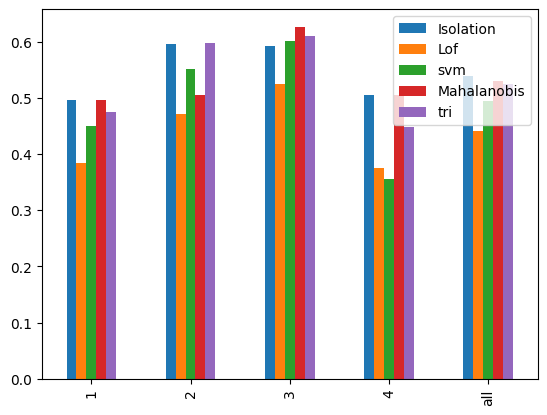

In [45]:
gmean_df.plot.bar()

In [4]:
from openai import OpenAI
client =OpenAI()

response = await client.responses.create({
    model: "gpt-4.1",
    input: "Write a one-sentence bedtime story about a unicorn."
});

print(response.output_text)

OpenAIError: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable